<a href="https://colab.research.google.com/github/SeanNamUIUC/Semiconductor-AnomalyDetection/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# EDA for Semiconductor Sensor Dataset
# =====================================


# 1. import numpy, pandas, matplotlib, seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. matplotlib inline 설정
%matplotlib inline


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
#master_df 형태
#|sample_id|timestamp|sensors(1 - 590)|label|


data_processed_parquet_path = "drive/MyDrive/Semiconductor-AnomalyDetection/data/processed/master_df.parquet"
data_processed_csv_path = "drive/MyDrive/Semiconductor-AnomalyDetection/data/processed/master_df.csv"
master_df = pd.read_parquet(data_processed_parquet_path)
print(master_df)



        sample_id           timestamp  sensor_001  sensor_002  sensor_003  \
0     sample_0001 2008-07-19 11:55:00     3030.93     2564.00   2187.7333   
1     sample_0002 2008-07-19 12:32:00     3095.78     2465.14   2230.4222   
2     sample_0003 2008-07-19 13:17:00     2932.61     2559.94   2186.4111   
3     sample_0004 2008-07-19 14:43:00     2988.72     2479.90   2199.0333   
4     sample_0005 2008-07-19 15:22:00     3032.24     2502.87   2233.3667   
...           ...                 ...         ...         ...         ...   
1562  sample_1563 2008-10-16 15:13:00     2899.41     2464.36   2179.7333   
1563  sample_1564 2008-10-16 20:49:00     3052.31     2522.55   2198.5667   
1564  sample_1565 2008-10-17 05:26:00     2978.81     2379.78   2206.3000   
1565  sample_1566 2008-10-17 06:01:00     2894.92     2532.01   2177.0333   
1566  sample_1567 2008-10-17 06:07:00     2944.92     2450.76   2195.4444   

      sensor_004  sensor_005  sensor_006  sensor_007  sensor_008  ...  \
0 

In [8]:
#1
# 1. Data Structure Summary (데이터 구조 이해)

# 1) master_df shape
samples, features = master_df.shape
print("\n Shape (rows, cols) is ", master_df.shape)

# 2 ) Role-based Feature Groups
#Sensor cols list -> 모델에 들어갈 실제 입력 features
sensor_cols = [col for col in master_df.columns if col.startswith("sensor_")]
#for data leakage prevention and to divide features based on importance
meta_cols = [col for col in master_df.columns if  not col.startswith("sensor_") and col != "label" ]

print("\n", sensor_cols)
print(meta_cols)

# 3 ) dtype check

print("\n", master_df[sensor_cols].dtypes.unique())
print(master_df[meta_cols + ["label"]].dtypes)

# 4 ) Samples vs Features Ratio (Samples per feature ratio was calculated using only input sensor features)
features = len(sensor_cols)
samples_per_feature = (samples / features)
print("\n samples_per_features: ", round(samples_per_feature, 3))

# 5 ) Baseline Accuracy
label_analysis = master_df["label"].value_counts()
print("\n Label Analysis \n ", label_analysis)
majority_class = label_analysis.idxmax()
baseline_accuracy = round((master_df["label"] == majority_class).mean() , 3)
print("\nBaseline Accuracy:", baseline_accuracy , "%")

# 6 ) High dimensional Risk statement (Based on rule of thumb)

if features >= samples:
    risk = "high (features >= samples)"
elif samples_per_feature < 5:
    risk = "moderate-high (samples/feature < 5)"
else:
    risk = "low-moderate"
print("\nHigh-dimensional tendency risk:", risk)


# range of datetime
start_time = master_df['timestamp'].min()
end_time = master_df['timestamp'].max()
print("\n", start_time,"~" , end_time)



 Shape (rows, cols) is  (1567, 593)

 ['sensor_001', 'sensor_002', 'sensor_003', 'sensor_004', 'sensor_005', 'sensor_006', 'sensor_007', 'sensor_008', 'sensor_009', 'sensor_010', 'sensor_011', 'sensor_012', 'sensor_013', 'sensor_014', 'sensor_015', 'sensor_016', 'sensor_017', 'sensor_018', 'sensor_019', 'sensor_020', 'sensor_021', 'sensor_022', 'sensor_023', 'sensor_024', 'sensor_025', 'sensor_026', 'sensor_027', 'sensor_028', 'sensor_029', 'sensor_030', 'sensor_031', 'sensor_032', 'sensor_033', 'sensor_034', 'sensor_035', 'sensor_036', 'sensor_037', 'sensor_038', 'sensor_039', 'sensor_040', 'sensor_041', 'sensor_042', 'sensor_043', 'sensor_044', 'sensor_045', 'sensor_046', 'sensor_047', 'sensor_048', 'sensor_049', 'sensor_050', 'sensor_051', 'sensor_052', 'sensor_053', 'sensor_054', 'sensor_055', 'sensor_056', 'sensor_057', 'sensor_058', 'sensor_059', 'sensor_060', 'sensor_061', 'sensor_062', 'sensor_063', 'sensor_064', 'sensor_065', 'sensor_066', 'sensor_067', 'sensor_068', 'sensor_

In [9]:
#전체 shape 확인


#feature type 분류 sensor/label/timestamp


#sample vs feature 비율 분석 -> 차원 과다 여부 판단


#baseline accuracy 계산 -> 모두 정상 예측시 정확도


#high dimensional risk 분석 -> overfitting 위험여부 분석

In [10]:
# 2. 클래스 불균형 분석
num_total = len(master_df['label'])
num_defective = (master_df['label'] == 1).sum()
num_finished = (master_df['label'] == -1).sum()
print("defective_product percentage is", ((num_defective / num_total) * 100 ))
master_df['timestamp'].is_monotonic_increasing




# Report
#New SECOM data is composed with 1567 samples and 591features including label and sample_id we created.
#This data is based on 3months. Defective_product percentage is 6.64% which shows that this data is highly unbalanced. Also we checked that the timestamp is sorted.

defective_product percentage is 6.636885768985322


True

         sensor  missing_percent  sensor_num
157  sensor_158        91.193363         158
158  sensor_159        91.193363         159
292  sensor_293        91.193363         293
293  sensor_294        91.193363         294
85   sensor_086        85.577537          86
..          ...              ...         ...
573  sensor_574         0.000000         574
574  sensor_575         0.000000         575
575  sensor_576         0.000000         576
576  sensor_577         0.000000         577
577  sensor_578         0.000000         578

[590 rows x 3 columns]
Top 20 Sensors by Missing Percentage
         sensor  missing_percent  sensor_num
157  sensor_158        91.193363         158
158  sensor_159        91.193363         159
292  sensor_293        91.193363         293
293  sensor_294        91.193363         294
85   sensor_086        85.577537          86
220  sensor_221        85.577537         221
358  sensor_359        85.577537         359
492  sensor_493        85.577537       

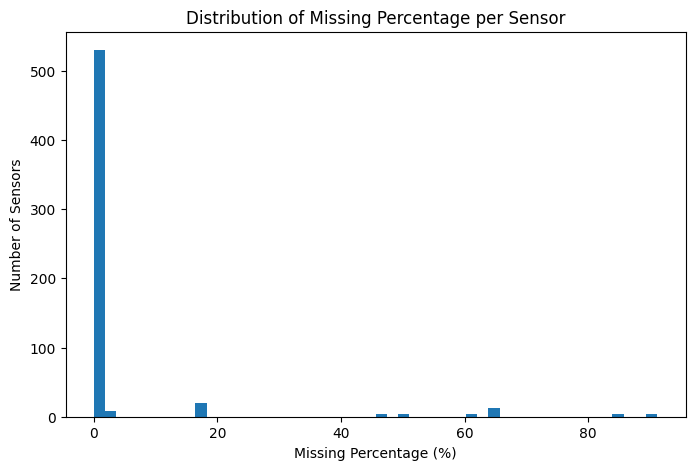


  50% 이상 결측 센서 개수: 28
         sensor  missing_percent  sensor_num
157  sensor_158        91.193363         158
158  sensor_159        91.193363         159
292  sensor_293        91.193363         293
293  sensor_294        91.193363         294
85   sensor_086        85.577537          86
220  sensor_221        85.577537         221
358  sensor_359        85.577537         359
492  sensor_493        85.577537         493
109  sensor_110        64.964901         110
110  sensor_111        64.964901         111
111  sensor_112        64.964901         112
244  sensor_245        64.964901         245
245  sensor_246        64.964901         246
246  sensor_247        64.964901         247
382  sensor_383        64.964901         383
383  sensor_384        64.964901         384
384  sensor_385        64.964901         385
516  sensor_517        64.964901         517
517  sensor_518        64.964901         518
518  sensor_519        64.964901         519
578  sensor_579        60.561583

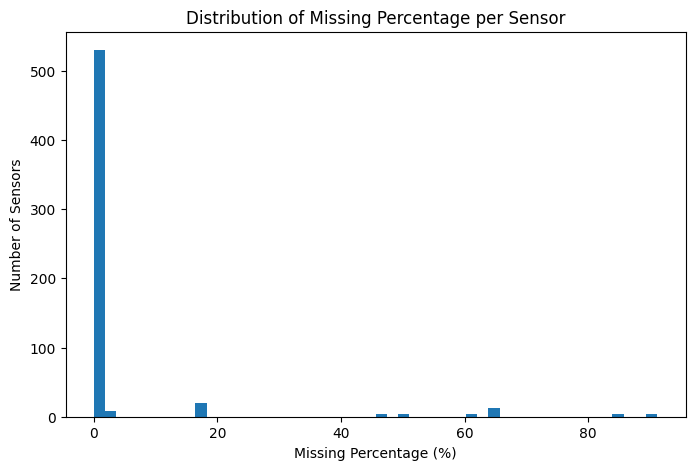

In [11]:


# 3. Missing Values (결측치 분석),

#센서별 결측치 비율 계산
sensor_cols = [cols for cols in master_df.columns if cols.startswith("sensor_")]
missing_percentage_per_cols = (master_df[sensor_cols].isnull().mean() * 100 ) #boolean values .mean() -> 전체 대비 True값들의 비율


#sorted_missing_percentage_per_cols changed datatype from series to dataframe to sort both key and value
missing_df = missing_percentage_per_cols.reset_index()
missing_df.columns = ["sensor", "missing_percent"]

#add sensor_number for sorting
missing_df["sensor_num"] = (
     missing_df["sensor"]
    .apply(lambda x: x.split("_")[1]) #숫자만 빼내서 정렬
    .astype(int)
)

sorted_missing_percentage_per_cols = missing_df.sort_values(
    by=["missing_percent", "sensor_num"],
    ascending=[False, True]
)
print(sorted_missing_percentage_per_cols)


print("Top 20 Sensors by Missing Percentage")
print(sorted_missing_percentage_per_cols.head(20))

#히스토그램
plt.figure(figsize=(8, 5))
plt.hist(missing_percentage_per_cols, bins=50)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Sensors")
plt.title("Distribution of Missing Percentage per Sensor")
plt.show()


# 7. 50% 이상 결측 센서
high_missing = sorted_missing_percentage_per_cols[sorted_missing_percentage_per_cols["missing_percent"] >= 50]

print("\n  50% 이상 결측 센서 개수:", len(high_missing))
print(high_missing)

# 8. 80% 이상 결측 센서
very_high_missing = sorted_missing_percentage_per_cols[sorted_missing_percentage_per_cols["missing_percent"] >= 80]

print("\n  80% 이상 결측 센서 개수:", len(very_high_missing))
print(very_high_missing)

# 9. 히스토그램 시각화
plt.figure(figsize=(8,5))
plt.hist(missing_df["missing_percent"], bins=50)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Sensors")
plt.title("Distribution of Missing Percentage per Sensor")
plt.show()


# multi key sorting, group pattern analysis, histogram based on sensors



In [12]:
#4. Feature Distribution 분석

In [13]:
#5. 분산 분석

In [14]:
#6. 상관관계 분석

In [15]:
#7. 시간 기반 분석